  JUMP.CDX1
  TWO-STAGE rocket
  Nose      : Conical  L=10.85"  D=2.12"
  BodyTube[0]: L=15.00"  D=2.12"  @ 10.85" from nose
  BodyTube[1]: L=36.00"  D=2.12"  @ 25.85" from nose  ← 4× fins root=8.0" tip=3.0" span=2.40"
  Booster   : L=60.00"  D=2.50"  ID=2.12"  @ 61.85" from nose
              4× fins root=6.5" tip=3.0" span=4.00"
  Sustainer length : 1.5710 m
  Booster   length : 1.5240 m
  Total    length  : 3.0950 m

  Simulation [0]:
    Sustainer : L2523  (BPS)  wt=11.0 lb  CG=36.0"
    Booster1  : M2380  (AeroTech)  wt=28.2 lb  CG=70.0"  ignition_delay=12.0s
    Results   : apogee=138250 ft  (42139 m)  t_apogee=97.3 s

  Simulation [1]:
    Sustainer : L2342  (BPS)  wt=10.0 lb  CG=36.0"
    Booster1  : M2380  (AeroTech)  wt=27.0 lb  CG=70.0"  ignition_delay=2.0s
    Results   : apogee=94022 ft  (28658 m)  t_apogee=69.1 s

── Building SUSTAINER ───────────────────────────────────────
[INFO] Sustainer mass from CDX1 launch weight: 4.990 kg — replace with actual dry mass!
[WARN] Sus

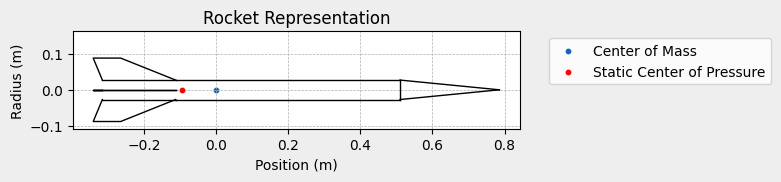

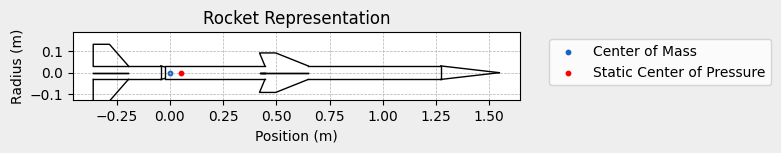

── CDX1 reference values ────────────────────────────────────────
  Launch altitude : 2000 ft  (609.6 m)
  Rail angle      : 2.0°
  Rail length     : 20.0 ft  (6.10 m)

  Simulation [0]:
    Sustainer motor : L2523  (BPS)
    Sustainer mass  : 11.00 lb  (4.990 kg)
    Sustainer CG    : 36.00"  (0.9144 m from nose)
    Booster motor   : M2380  (AeroTech)
    Booster mass    : 28.20 lb  (12.791 kg)
    Booster CG      : 70.00"  (1.7780 m from nose)
    Sustainer ignition delay: 12.0 s
    Predicted apogee: 138250 ft  (42139 m)  @ t=97.3 s

  Simulation [1]:
    Sustainer motor : L2342  (BPS)
    Sustainer mass  : 10.00 lb  (4.536 kg)
    Sustainer CG    : 36.00"  (0.9144 m from nose)
    Booster motor   : M2380  (AeroTech)
    Booster mass    : 27.00 lb  (12.247 kg)
    Booster CG      : 70.00"  (1.7780 m from nose)
    Sustainer ignition delay: 2.0 s
    Predicted apogee: 94022 ft  (28658 m)  @ t=69.1 s
─────────────────────────────────────────────────────────────────


In [1]:
# %% [markdown]
# # RASAero II CDX1 → RocketPy Converter
#
# Supports **single-stage** and **two-stage** (sustainer + Booster 1) rockets.
#
# **Units:** RASAero stores lengths in **inches**, masses in **pounds**.
# RocketPy expects **metres** and **kilograms**. All conversions are automatic.
#
# **Coordinate system:** RocketPy uses `"tail_to_nose"` with the user-chosen
# origin (default: centre of dry mass = 0).  RASAero measures everything from
# the nose tip (nose-to-tail, increasing downward).  The converter handles the
# flip automatically for every component position.
#
# **Two-stage workflow (RocketPy):**
#   1. Simulate the *full stacked rocket* (sustainer + booster) until separation.
#   2. Simulate the *sustainer alone*, starting from the separation state vector.
#
# Both `Rocket` objects are returned; you attach motors and run `Flight` yourself.

# %% [markdown]
# ## 1 · Imports

# %%
import xml.etree.ElementTree as ET
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional
import numpy as np

# Install with:  pip install rocketpy
from rocketpy import Rocket

# %% [markdown]
# ## 2 · Unit-conversion helpers

# %%
IN2M  = 0.0254
LB2KG = 0.453592
FT2M  = 0.3048


def in_to_m(v: float) -> float:
    return float(v) * IN2M


def lb_to_kg(v: float) -> float:
    return float(v) * LB2KG


def _float(el, tag: str, default: float = 0.0) -> float:
    node = el.find(tag)
    if node is None or not (node.text or "").strip():
        return default
    return float(node.text.strip())


def _str(el, tag: str, default: str = "") -> str:
    node = el.find(tag)
    return (node.text or "").strip() if node is not None else default


def _bool_str(el, tag: str, default: bool = False) -> bool:
    node = el.find(tag)
    if node is None:
        return default
    return (node.text or "").strip().lower() == "true"


# %% [markdown]
# ## 3 · Data classes for parsed components

# %%
@dataclass
class ParsedNose:
    length_in: float
    diameter_in: float
    shape: str
    location_in: float  # nose tip from origin (always 0 in RASAero)


@dataclass
class ParsedFin:
    count: int
    root_chord_in: float
    tip_chord_in: float
    span_in: float
    sweep_in: float
    thickness_in: float
    location_in: float  # from front of parent tube
    airfoil_section: str


@dataclass
class ParsedBodyTube:
    length_in: float
    diameter_in: float
    location_in: float          # nose-to-tail position of tube front
    boattail_length_in: float
    boattail_rear_dia_in: float
    fin: Optional[ParsedFin] = None   # fins mounted directly on this tube


@dataclass
class ParsedBooster:
    """Represents a RASAero <Booster> — the external booster stage."""
    length_in: float
    diameter_in: float          # outer diameter of booster body
    inside_diameter_in: float   # inner coupler / shoulder diameter
    location_in: float          # nose-to-tail position of booster front
    shoulder_length_in: float
    boattail_length_in: float
    boattail_rear_dia_in: float
    fin: Optional[ParsedFin] = None


@dataclass
class ParsedSimulation:
    # Sustainer
    sustainer_engine: str
    sustainer_launch_wt_lb: float
    sustainer_cg_in: float
    sustainer_nozzle_dia_in: float
    sustainer_ignition_delay_s: float
    # Booster 1
    booster1_engine: str
    booster1_launch_wt_lb: float
    booster1_cg_in: float
    booster1_nozzle_dia_in: float
    booster1_separation_delay_s: float
    booster1_ignition_delay_s: float
    include_booster1: bool
    # Results (reference only)
    time_to_apogee_s: float
    max_altitude_ft: float
    max_velocity_fps: float


@dataclass
class ParsedLaunchSite:
    altitude_ft: float
    rod_angle_deg: float
    rod_length_ft: float
    temperature_f: float
    wind_speed_mph: float


@dataclass
class ParsedRecovery:
    device_type_1: str
    size_1_in: float
    cd_1: float
    altitude_1_ft: float
    device_type_2: str
    size_2_in: float
    cd_2: float
    altitude_2_ft: float


# %% [markdown]
# ## 4 · CDX1 Parser

# %%
NOSE_SHAPE_MAP = {
    "Conical":       "conical",
    "Ogive":         "ogive",
    "Tangent Ogive": "ogive",
    "Power Series":  "powerseries",
    "Parabolic":     "parabolic",
    "Von Karman":    "vonkarman",
    "Haack":         "lvhaack",
    "Elliptical":    "elliptical",
}


def _parse_fin_node(node) -> Optional[ParsedFin]:
    if node is None:
        return None
    return ParsedFin(
        count=int(_float(node, "Count", 3)),
        root_chord_in=_float(node, "Chord"),
        tip_chord_in=_float(node, "TipChord"),
        span_in=_float(node, "Span"),
        sweep_in=_float(node, "SweepDistance"),
        thickness_in=_float(node, "Thickness"),
        location_in=_float(node, "Location"),
        airfoil_section=_str(node, "AirfoilSection", "Flat"),
    )


class CDX1Parser:
    """
    Parse a RASAero II CDX1 file.

    Attributes
    ----------
    nose          : ParsedNose
    body_tubes    : list[ParsedBodyTube]   — all <BodyTube> elements, in order
    booster       : ParsedBooster | None   — <Booster> element if present
    simulations   : list[ParsedSimulation] — all <Simulation> entries
    launch_site   : ParsedLaunchSite | None
    recovery      : ParsedRecovery | None
    is_two_stage  : bool                   — True if a Booster is present
    """

    def __init__(self, filepath):
        self.filepath = Path(filepath)
        tree = ET.parse(self.filepath)
        self.root = tree.getroot()
        design = self.root.find("RocketDesign")
        if design is None:
            raise ValueError("No <RocketDesign> found in CDX1 file.")
        self._design = design
        self._parse()

    # ------------------------------------------------------------------ #
    # Parsing                                                               #
    # ------------------------------------------------------------------ #

    def _parse(self):
        d = self._design

        # Nose
        nose_node = d.find("NoseCone")
        if nose_node is None:
            raise ValueError("CDX1 has no <NoseCone>.")
        self.nose = ParsedNose(
            length_in=_float(nose_node, "Length"),
            diameter_in=_float(nose_node, "Diameter"),
            shape=_str(nose_node, "Shape", "Conical"),
            location_in=_float(nose_node, "Location"),
        )

        # All BodyTubes (may be multiple for two-stage)
        self.body_tubes: list[ParsedBodyTube] = []
        for bt in d.findall("BodyTube"):
            self.body_tubes.append(ParsedBodyTube(
                length_in=_float(bt, "Length"),
                diameter_in=_float(bt, "Diameter"),
                location_in=_float(bt, "Location"),
                boattail_length_in=_float(bt, "BoattailLength"),
                boattail_rear_dia_in=_float(bt, "BoattailRearDiameter"),
                fin=_parse_fin_node(bt.find("Fin")),
            ))

        if not self.body_tubes:
            raise ValueError("CDX1 has no <BodyTube> elements.")

        # Legacy single <FinCan> (single-stage rockets)
        fincan_node = d.find("FinCan")
        self._fincan = None
        if fincan_node is not None:
            from dataclasses import make_dataclass
            self._fincan = {
                "length_in":          _float(fincan_node, "Length"),
                "diameter_in":        _float(fincan_node, "Diameter"),
                "inside_diameter_in": _float(fincan_node, "InsideDiameter"),
                "location_in":        _float(fincan_node, "Location"),
                "shoulder_length_in": _float(fincan_node, "ShoulderLength"),
                "fin": _parse_fin_node(fincan_node.find("Fin")),
            }

        # Booster (two-stage)
        booster_node = d.find("Booster")
        self.booster: Optional[ParsedBooster] = None
        if booster_node is not None:
            self.booster = ParsedBooster(
                length_in=_float(booster_node, "Length"),
                diameter_in=_float(booster_node, "Diameter"),
                inside_diameter_in=_float(booster_node, "InsideDiameter"),
                location_in=_float(booster_node, "Location"),
                shoulder_length_in=_float(booster_node, "ShoulderLength"),
                boattail_length_in=_float(booster_node, "BoattailLength"),
                boattail_rear_dia_in=_float(booster_node, "BoattailRearDiameter"),
                fin=_parse_fin_node(booster_node.find("Fin")),
            )

        self.is_two_stage = self.booster is not None

        # Simulations
        self.simulations: list[ParsedSimulation] = []
        sim_list = self.root.find("SimulationList")
        if sim_list is not None:
            for sim in sim_list.findall("Simulation"):
                self.simulations.append(ParsedSimulation(
                    sustainer_engine=_str(sim, "SustainerEngine"),
                    sustainer_launch_wt_lb=_float(sim, "SustainerLaunchWt"),
                    sustainer_cg_in=_float(sim, "SustainerCG"),
                    sustainer_nozzle_dia_in=_float(sim, "SustainerNozzleDiameter"),
                    sustainer_ignition_delay_s=_float(sim, "SustainerIgnitionDelay"),
                    booster1_engine=_str(sim, "Booster1Engine"),
                    booster1_launch_wt_lb=_float(sim, "Booster1LaunchWt"),
                    booster1_cg_in=_float(sim, "Booster1CG"),
                    booster1_nozzle_dia_in=_float(sim, "Booster1NozzleDiameter"),
                    booster1_separation_delay_s=_float(sim, "Booster1SeparationDelay"),
                    booster1_ignition_delay_s=_float(sim, "Booster1IgnitionDelay"),
                    include_booster1=_bool_str(sim, "IncludeBooster1"),
                    time_to_apogee_s=_float(sim, "TimetoApogee"),
                    max_altitude_ft=_float(sim, "MaxAltitude"),
                    max_velocity_fps=_float(sim, "MaxVelocity"),
                ))

        # Launch site
        site = self.root.find("LaunchSite")
        self.launch_site = ParsedLaunchSite(
            altitude_ft=_float(site, "Altitude") if site is not None else 0,
            rod_angle_deg=_float(site, "RodAngle") if site is not None else 0,
            rod_length_ft=_float(site, "RodLength") if site is not None else 10,
            temperature_f=_float(site, "Temperature", 59) if site is not None else 59,
            wind_speed_mph=_float(site, "WindSpeed") if site is not None else 0,
        ) if site is not None else None

        # Recovery
        rec = self.root.find("Recovery")
        self.recovery = ParsedRecovery(
            device_type_1=_str(rec, "DeviceType1", "None"),
            size_1_in=_float(rec, "Size1", 1),
            cd_1=_float(rec, "CD1", 1.33),
            altitude_1_ft=_float(rec, "Altitude1", 1000),
            device_type_2=_str(rec, "DeviceType2", "None"),
            size_2_in=_float(rec, "Size2", 1),
            cd_2=_float(rec, "CD2", 1.33),
            altitude_2_ft=_float(rec, "Altitude2", 0),
        ) if rec is not None else None

    # ------------------------------------------------------------------ #
    # Derived geometry helpers                                              #
    # ------------------------------------------------------------------ #

    @property
    def sustainer_radius_m(self) -> float:
        """Max radius of the sustainer (nose + body tubes) in metres."""
        return in_to_m(self.body_tubes[0].diameter_in) / 2.0

    @property
    def booster_radius_m(self) -> float:
        """Outer radius of the booster body in metres (0 if single-stage)."""
        if self.booster is None:
            return self.sustainer_radius_m
        return in_to_m(self.booster.diameter_in) / 2.0

    @property
    def sustainer_length_m(self) -> float:
        """Length of the sustainer section (nose + all body tubes + fincan) in metres."""
        total = in_to_m(self.nose.length_in)
        for bt in self.body_tubes:
            total += in_to_m(bt.length_in)
        # Include FinCan if present (single-stage designs with a <FinCan> element)
        if self._fincan is not None:
            total += in_to_m(self._fincan["length_in"])
        return total

    @property
    def booster_length_m(self) -> float:
        """Length of the booster section in metres (0 if single-stage)."""
        if self.booster is None:
            return 0.0
        return in_to_m(self.booster.length_in)

    @property
    def total_stacked_length_m(self) -> float:
        """Full rocket length nose-tip to tail in metres."""
        return self.sustainer_length_m + self.booster_length_m

    # ------------------------------------------------------------------ #
    # Summary                                                               #
    # ------------------------------------------------------------------ #

    def summary(self):
        w = 64
        print("=" * w)
        print(f"  {self.filepath.name}")
        print(f"  {'TWO-STAGE' if self.is_two_stage else 'SINGLE-STAGE'} rocket")
        print("=" * w)
        n = self.nose
        print(f"  Nose      : {n.shape}  L={n.length_in:.2f}\"  D={n.diameter_in:.2f}\"")
        for i, bt in enumerate(self.body_tubes):
            label = f"  BodyTube[{i}]"
            fin_info = ""
            if bt.fin:
                f = bt.fin
                fin_info = (f"  ← {f.count}× fins root={f.root_chord_in:.1f}\""
                            f" tip={f.tip_chord_in:.1f}\" span={f.span_in:.2f}\"")
            print(f"{label}: L={bt.length_in:.2f}\"  D={bt.diameter_in:.2f}\""
                  f"  @ {bt.location_in:.2f}\" from nose{fin_info}")
        if self._fincan:
            fc = self._fincan
            print(f"  FinCan    : L={fc['length_in']:.2f}\"  D={fc['diameter_in']:.2f}\""
                  f"  @ {fc['location_in']:.2f}\" from nose")
            if fc["fin"]:
                f = fc["fin"]
                print(f"              {f.count}× fins root={f.root_chord_in:.1f}\""
                      f" tip={f.tip_chord_in:.1f}\" span={f.span_in:.2f}\"")
        if self.booster:
            b = self.booster
            print(f"  Booster   : L={b.length_in:.2f}\"  D={b.diameter_in:.2f}\""
                  f"  ID={b.inside_diameter_in:.2f}\"  @ {b.location_in:.2f}\" from nose")
            if b.fin:
                f = b.fin
                print(f"              {f.count}× fins root={f.root_chord_in:.1f}\""
                      f" tip={f.tip_chord_in:.1f}\" span={f.span_in:.2f}\"")
        print(f"  Sustainer length : {self.sustainer_length_m:.4f} m")
        if self.is_two_stage:
            print(f"  Booster   length : {self.booster_length_m:.4f} m")
            print(f"  Total    length  : {self.total_stacked_length_m:.4f} m")
        if self.simulations:
            for i, s in enumerate(self.simulations):
                print(f"\n  Simulation [{i}]:")
                print(f"    Sustainer : {s.sustainer_engine}"
                      f"  wt={s.sustainer_launch_wt_lb:.1f} lb"
                      f"  CG={s.sustainer_cg_in:.1f}\"")
                if s.include_booster1:
                    print(f"    Booster1  : {s.booster1_engine}"
                          f"  wt={s.booster1_launch_wt_lb:.1f} lb"
                          f"  CG={s.booster1_cg_in:.1f}\""
                          f"  ignition_delay={s.sustainer_ignition_delay_s:.1f}s")
                print(f"    Results   : apogee={s.max_altitude_ft:.0f} ft"
                      f"  ({s.max_altitude_ft*FT2M:.0f} m)"
                      f"  t_apogee={s.time_to_apogee_s:.1f} s")
        print("=" * w)


# %% [markdown]
# ## 5 · Inertia estimator

# %%
def _estimate_inertia(mass_kg: float, length_m: float, radius_m: float,
                      label: str) -> tuple[float, float]:
    """
    Rough inertia estimates for a thin-walled cylinder.
    Returns (I_lateral, I_axial) in kg·m².
    Always prints a warning — replace with accurate values.
    """
    I_lat = mass_kg * (3 * radius_m**2 + length_m**2) / 12.0
    I_ax  = mass_kg * radius_m**2 / 2.0
    print(f"[WARN] {label}: inertia estimated from geometry "
          f"(I_lat={I_lat:.4f}, I_ax={I_ax:.6f} kg·m²) — provide accurate values!")
    return I_lat, I_ax


# %% [markdown]
# ## 6 · Core rocket builder (used for both sustainer and full stack)

# %%
def _build_rocket(
    name: str,
    radius_m: float,
    length_m: float,
    mass_kg: float,
    inertia_i: float,
    inertia_z: float,
    power_off_drag,
    power_on_drag,
    com_position: float,
    components: list,          # list of callables: fn(rocket, nt_to_rpy)
) -> Rocket:
    """
    Instantiate a Rocket and add all components via the provided callables.
    `components` is a list of (fn, kwargs) where fn(rocket, nt_to_rpy_fn).
    """
    rocket = Rocket(
        radius=radius_m,
        mass=mass_kg,
        inertia=(inertia_i, inertia_i, inertia_z),
        power_off_drag=power_off_drag,
        power_on_drag=power_on_drag,
        center_of_mass_without_motor=com_position,
        coordinate_system_orientation="tail_to_nose",
    )

    half_L = length_m / 2.0

    def nt_to_rpy(pos_nt_m: float) -> float:
        """Nose-to-tail (m) → RocketPy tail-to-nose coord (m), origin at CoM."""
        return half_L - pos_nt_m + com_position

    for fn in components:
        fn(rocket, nt_to_rpy)

    return rocket


# %% [markdown]
# ## 7 · Component-adder factories

# %%
def _add_nose_fn(nose: ParsedNose):
    """Return a component function that adds a nose cone."""
    kind = NOSE_SHAPE_MAP.get(nose.shape)
    if kind is None:
        print(f"[WARN] Unknown nose shape '{nose.shape}'; defaulting to 'conical'.")
        kind = "conical"
    length_m = in_to_m(nose.length_in)

    def fn(rocket: Rocket, nt_to_rpy):
        tip_pos = nt_to_rpy(0.0)
        rocket.add_nose(length=length_m, kind=kind, position=tip_pos, name="NoseCone")
        print(f"  [NoseCone] {kind}  L={length_m:.4f} m  tip@{tip_pos:+.4f} m")
    return fn


def _add_fins_fn(fin: ParsedFin, parent_front_nt_m: float, label: str = "Fins"):
    """Return a component function that adds a trapezoidal fin set."""
    root_m  = in_to_m(fin.root_chord_in)
    tip_m   = in_to_m(fin.tip_chord_in)
    span_m  = in_to_m(fin.span_in)
    sweep_m = in_to_m(fin.sweep_in)
    # Fin <Location> in RASAero is the axial distance from the parent tube's
    # front face to the fin root LEADING EDGE.
    fin_le_nt_m = parent_front_nt_m + in_to_m(fin.location_in)

    def fn(rocket: Rocket, nt_to_rpy):
        pos = nt_to_rpy(fin_le_nt_m)
        rocket.add_trapezoidal_fins(
            n=fin.count,
            root_chord=root_m,
            tip_chord=tip_m,
            span=span_m,
            position=pos,
            sweep_length=sweep_m,
            cant_angle=0,
            name=label,
        )
        print(f"  [{label}] n={fin.count}  root={root_m:.4f} m  tip={tip_m:.4f} m"
              f"  span={span_m:.4f} m  sweep={sweep_m:.4f} m  LE@{pos:+.4f} m")
    return fn


def _add_tail_fn(top_r_m: float, bot_r_m: float, length_m: float,
                 top_nt_m: float, label: str = "Tail"):
    """Return a component function that adds a tail / boattail."""
    def fn(rocket: Rocket, nt_to_rpy):
        pos = nt_to_rpy(top_nt_m)
        rocket.add_tail(
            top_radius=top_r_m,
            bottom_radius=bot_r_m,
            length=length_m,
            position=pos,
            name=label,
        )
        print(f"  [{label}] top_r={top_r_m:.4f} m  bot_r={bot_r_m:.4f} m"
              f"  L={length_m:.4f} m  top@{pos:+.4f} m")
    return fn


# %% [markdown]
# ## 8 · Sustainer builder

# %%
def _build_sustainer(
    parser: CDX1Parser,
    sim: ParsedSimulation,
    mass_kg: Optional[float],
    inertia_i: Optional[float],
    inertia_z: Optional[float],
    power_off_drag,
    power_on_drag,
) -> Rocket:
    """Build and return the RocketPy Rocket for the sustainer stage."""

    print("\n── Building SUSTAINER ───────────────────────────────────────")

    L = parser.sustainer_length_m
    R = parser.sustainer_radius_m

    if mass_kg is None:
        mass_kg = lb_to_kg(sim.sustainer_launch_wt_lb)
        print(f"[INFO] Sustainer mass from CDX1 launch weight: {mass_kg:.3f} kg"
              " — replace with actual dry mass!")
    if inertia_i is None or inertia_z is None:
        ei, ez = _estimate_inertia(mass_kg, L, R, "Sustainer")
        inertia_i = inertia_i or ei
        inertia_z = inertia_z or ez

    # Accumulate component functions (nose-to-tail order)
    components = []

    # Nose cone
    components.append(_add_nose_fn(parser.nose))

    # Body tubes — may carry fins directly (two-stage layout)
    # or be the single cylindrical body (single-stage layout).
    for bt in parser.body_tubes:
        bt_front_nt_m = in_to_m(bt.location_in)
        if bt.fin is not None:
            components.append(_add_fins_fn(bt.fin, bt_front_nt_m,
                                           label="SustainerFins"))
        if bt.boattail_length_in > 0:
            body_end_nt = bt_front_nt_m + in_to_m(bt.length_in)
            components.append(_add_tail_fn(
                top_r_m=in_to_m(bt.diameter_in) / 2.0,
                bot_r_m=in_to_m(bt.boattail_rear_dia_in) / 2.0,
                length_m=in_to_m(bt.boattail_length_in),
                top_nt_m=body_end_nt,
                label="SustainerBoattail",
            ))

    # Legacy FinCan (single-stage files with a <FinCan> element)
    if parser._fincan is not None:
        fc = parser._fincan
        fc_front_nt_m = in_to_m(fc["location_in"])
        if fc["fin"] is not None:
            components.append(_add_fins_fn(fc["fin"], fc_front_nt_m,
                                           label="Fins"))

    rocket = _build_rocket(
        name="Sustainer",
        radius_m=R,
        length_m=L,
        mass_kg=mass_kg,
        inertia_i=inertia_i,
        inertia_z=inertia_z,
        power_off_drag=power_off_drag,
        power_on_drag=power_on_drag,
        com_position=0.0,
        components=components,
    )

    print(f"\n  Sustainer: L={L:.4f} m  R={R:.4f} m  mass={mass_kg:.3f} kg")
    print("  ✅  Sustainer rocket built.")
    return rocket


# %% [markdown]
# ## 9 · Full stacked rocket builder (booster + sustainer together)

# %%
def _build_full_stack(
    parser: CDX1Parser,
    sim: ParsedSimulation,
    sustainer_mass_kg: Optional[float],
    booster_mass_kg: Optional[float],
    stack_inertia_i: Optional[float],
    stack_inertia_z: Optional[float],
    power_off_drag,
    power_on_drag,
) -> Rocket:
    """
    Build the full stacked rocket (sustainer on top + booster below).

    The full stack is treated as ONE RocketPy Rocket for the boost phase.
    Its total length = sustainer_length + booster_length.
    The booster's fins and body are added as aerodynamic surfaces.
    The single motor attached should be the booster motor.
    """

    print("\n── Building FULL STACK (Sustainer + Booster) ────────────────")

    b = parser.booster
    L_sus = parser.sustainer_length_m
    L_bst = parser.booster_length_m
    L     = parser.total_stacked_length_m
    R     = parser.booster_radius_m   # booster is the widest part

    # Total stack mass: use sum of CDX1 launch weights as proxy
    if sustainer_mass_kg is None:
        sustainer_mass_kg = lb_to_kg(sim.sustainer_launch_wt_lb)
        print(f"[INFO] Sustainer mass proxy: {sustainer_mass_kg:.3f} kg")
    if booster_mass_kg is None:
        booster_mass_kg = lb_to_kg(sim.booster1_launch_wt_lb)
        print(f"[INFO] Booster mass proxy: {booster_mass_kg:.3f} kg")

    total_mass_kg = sustainer_mass_kg + booster_mass_kg

    if stack_inertia_i is None or stack_inertia_z is None:
        ei, ez = _estimate_inertia(total_mass_kg, L, R, "Full Stack")
        stack_inertia_i = stack_inertia_i or ei
        stack_inertia_z = stack_inertia_z or ez

    # Collect component adders (all in nose-to-tail order across the full stack)
    components = []

    # ── Sustainer aerodynamic surfaces ──────────────────────────────────
    # Nose
    components.append(_add_nose_fn(parser.nose))

    # Sustainer body tubes and their fins
    for bt in parser.body_tubes:
        bt_front_nt_m = in_to_m(bt.location_in)
        if bt.fin is not None:
            components.append(_add_fins_fn(bt.fin, bt_front_nt_m,
                                           label="SustainerFins"))
        if bt.boattail_length_in > 0:
            body_end_nt = bt_front_nt_m + in_to_m(bt.length_in)
            components.append(_add_tail_fn(
                top_r_m=in_to_m(bt.diameter_in) / 2.0,
                bot_r_m=in_to_m(bt.boattail_rear_dia_in) / 2.0,
                length_m=in_to_m(bt.boattail_length_in),
                top_nt_m=body_end_nt,
                label="SustainerBoattail",
            ))

    # Legacy FinCan (single-stage CDX1 files won't get here, but be safe)
    if parser._fincan is not None:
        fc = parser._fincan
        fc_front_nt_m = in_to_m(fc["location_in"])
        if fc["fin"] is not None:
            components.append(_add_fins_fn(fc["fin"], fc_front_nt_m,
                                           label="SustainerFins"))

    # ── Booster aerodynamic surfaces ────────────────────────────────────
    # The booster starts at L_sus (nose-to-tail) in the full stack frame.
    booster_front_nt_m = L_sus

    # Shoulder / coupler transition: the booster body is wider than the
    # sustainer.  Model this as a Tail going from sustainer radius to
    # booster outer radius over the shoulder length.
    if b.shoulder_length_in > 0 and b.diameter_in > parser.body_tubes[-1].diameter_in:
        shoulder_len_m  = in_to_m(b.shoulder_length_in)
        sustainer_bot_r = in_to_m(parser.body_tubes[-1].diameter_in) / 2.0
        booster_top_r   = in_to_m(b.diameter_in) / 2.0
        components.append(_add_tail_fn(
            top_r_m=sustainer_bot_r,
            bot_r_m=booster_top_r,
            length_m=shoulder_len_m,
            top_nt_m=booster_front_nt_m,
            label="BoosterShoulder",
        ))

    # Booster fins
    if b.fin is not None:
        components.append(_add_fins_fn(b.fin, booster_front_nt_m,
                                       label="BoosterFins"))

    # Booster boattail
    if b.boattail_length_in > 0:
        booster_end_nt = booster_front_nt_m + in_to_m(b.length_in)
        components.append(_add_tail_fn(
            top_r_m=in_to_m(b.diameter_in) / 2.0,
            bot_r_m=in_to_m(b.boattail_rear_dia_in) / 2.0,
            length_m=in_to_m(b.boattail_length_in),
            top_nt_m=booster_end_nt,
            label="BoosterBoattail",
        ))

    rocket = _build_rocket(
        name="FullStack",
        radius_m=R,
        length_m=L,
        mass_kg=total_mass_kg,
        inertia_i=stack_inertia_i,
        inertia_z=stack_inertia_z,
        power_off_drag=power_off_drag,
        power_on_drag=power_on_drag,
        com_position=0.0,
        components=components,
    )

    print(f"\n  Full stack: L={L:.4f} m  R={R:.4f} m"
          f"  total_mass={total_mass_kg:.3f} kg")
    print("  ✅  Full-stack rocket built.")
    return rocket


# %% [markdown]
# ## 10 · Public API — `build_rocketpy_rocket`

# %%
def build_rocketpy_rocket(
    cdx1_path: str,
    *,
    simulation_index: int = 0,
    # Sustainer
    sustainer_mass_kg: Optional[float] = None,
    sustainer_inertia_i: Optional[float] = None,
    sustainer_inertia_z: Optional[float] = None,
    # Booster (two-stage only)
    booster_mass_kg: Optional[float] = None,
    stack_inertia_i: Optional[float] = None,
    stack_inertia_z: Optional[float] = None,
    # Aerodynamics
    power_off_drag=0.5,
    power_on_drag=0.5,
):
    """
    Parse a RASAero II CDX1 file and build RocketPy ``Rocket`` objects.

    Single-stage
    ------------
    Returns ``(sustainer, None, parser)``.
    Attach your motor then simulate::

        sustainer.add_motor(motor, position=nozzle_pos_m)
        flight = Flight(rocket=sustainer, environment=env, ...)

    Two-stage
    ---------
    Returns ``(sustainer, full_stack, parser)``.

    * ``full_stack`` represents the complete stacked rocket during the boost
      phase.  Attach the **booster motor** to it and simulate until separation::

          full_stack.add_motor(booster_motor, position=booster_nozzle_pos_m)
          boost_phase = Flight(
              rocket=full_stack, environment=env,
              rail_length=rail_length_m,
              terminate_on_apogee=False,
              max_time=separation_time_s,   # ← stop at stage separation
          )

    * ``sustainer`` represents only the upper stage.  Attach the **sustainer
      motor** and continue the simulation from the separation state::

          sustainer.add_motor(sustainer_motor, position=sustainer_nozzle_pos_m)
          sustainer_phase = Flight(
              rocket=sustainer, environment=env,
              initial_solution=boost_phase,  # picks up position/velocity
          )

    Parameters
    ----------
    cdx1_path : str
        Path to the ``.CDX1`` file.
    simulation_index : int
        Which ``<Simulation>`` entry to use for mass/CG reference (default 0).
    sustainer_mass_kg : float, optional
        Dry mass of the sustainer (airframe + empty sustainer motor) in kg.
        Falls back to CDX1 launch weight if omitted (prints a warning).
    sustainer_inertia_i : float, optional
        Sustainer lateral moment of inertia I₁₁ = I₂₂ in kg·m².
    sustainer_inertia_z : float, optional
        Sustainer axial moment of inertia I₃₃ in kg·m².
    booster_mass_kg : float, optional
        Dry mass of the booster stage in kg (two-stage only).
    stack_inertia_i : float, optional
        Full-stack lateral moment of inertia in kg·m² (two-stage only).
    stack_inertia_z : float, optional
        Full-stack axial moment of inertia in kg·m² (two-stage only).
    power_off_drag : float or str
        Drag coefficient (constant or CSV path) with motor off.
    power_on_drag : float or str
        Drag coefficient (constant or CSV path) with motor on.

    Returns
    -------
    sustainer : rocketpy.Rocket
        The sustainer (upper) stage.
    full_stack : rocketpy.Rocket or None
        The full stacked rocket (two-stage only); ``None`` for single-stage.
    parser : CDX1Parser
        Raw parsed data for further inspection.
    """

    parser = CDX1Parser(cdx1_path)
    parser.summary()

    if not parser.simulations:
        raise ValueError("CDX1 file contains no <Simulation> entries.")
    if simulation_index >= len(parser.simulations):
        raise ValueError(
            f"simulation_index={simulation_index} but only "
            f"{len(parser.simulations)} simulation(s) found."
        )
    sim = parser.simulations[simulation_index]

    # ── Single-stage ────────────────────────────────────────────────────
    if not parser.is_two_stage:
        sustainer = _build_sustainer(
            parser, sim,
            sustainer_mass_kg, sustainer_inertia_i, sustainer_inertia_z,
            power_off_drag, power_on_drag,
        )
        _print_motor_hint(parser, sim, sustainer, is_two_stage=False)
        return sustainer, None, parser

    # ── Two-stage ───────────────────────────────────────────────────────
    sustainer = _build_sustainer(
        parser, sim,
        sustainer_mass_kg, sustainer_inertia_i, sustainer_inertia_z,
        power_off_drag, power_on_drag,
    )
    full_stack = _build_full_stack(
        parser, sim,
        sustainer_mass_kg, booster_mass_kg,
        stack_inertia_i, stack_inertia_z,
        power_off_drag, power_on_drag,
    )
    _print_motor_hint(parser, sim, full_stack, is_two_stage=True)
    return sustainer, full_stack, parser


def _print_motor_hint(parser: CDX1Parser, sim: ParsedSimulation,
                      rocket: Rocket, is_two_stage: bool):
    L_sus = parser.sustainer_length_m
    L_tot = parser.total_stacked_length_m

    print("\n" + "─" * 64)
    if is_two_stage:
        # Booster nozzle is at very bottom of the full stack
        bst_nozzle_m = -(L_tot / 2.0)
        # Sustainer nozzle is at the bottom of the sustainer section
        sus_nozzle_m = -(L_sus / 2.0)
        print("NEXT STEPS — two-stage:")
        print(f"  1. Attach BOOSTER motor to full_stack:")
        print(f"       booster_nozzle_pos ≈ {bst_nozzle_m:.4f} m  (refine with motor file)")
        print(f"       full_stack.add_motor(booster_motor, position={bst_nozzle_m:.4f})")
        print(f"  2. Run boost-phase flight (set max_time to separation):")
        print(f"       separation_delay = {sim.booster1_separation_delay_s} s"
              f"  ignition_delay = {sim.sustainer_ignition_delay_s} s")
        print(f"       boost_flight = Flight(rocket=full_stack, ..., max_time=<sep_time>)")
        print(f"  3. Attach SUSTAINER motor to sustainer:")
        print(f"       sustainer_nozzle_pos ≈ {sus_nozzle_m:.4f} m")
        print(f"       sustainer.add_motor(sustainer_motor, position={sus_nozzle_m:.4f})")
        print(f"  4. Continue from separation state:")
        print(f"       sustainer_flight = Flight(rocket=sustainer, ...,")
        print(f"                                  initial_solution=boost_flight)")
        print(f"  CDX1 engines: Booster={sim.booster1_engine}"
              f"  Sustainer={sim.sustainer_engine}")
    else:
        nozzle_m = -(L_sus / 2.0)
        print("NEXT STEPS — single-stage:")
        print(f"  1. Attach motor:  rocket.add_motor(motor, position={nozzle_m:.4f})")
        print(f"  2. Run:           Flight(rocket=rocket, environment=env, ...)")
        print(f"  CDX1 engine: {sim.sustainer_engine}")
    print("─" * 64 + "\n")


# %% [markdown]
# ## 11 · Run the converter
#
# Change `CDX1_FILE` to point at your file.
# For a **single-stage** rocket, `full_stack` will be `None`.
# For a **two-stage** rocket, both `sustainer` and `full_stack` are returned.

# %%
CDX1_FILE = "JUMP.CDX1"   # ← change to your file path

# Optional: provide accurate values to replace geometric estimates.
# For two-stage rockets, sustainer_* refers to the upper stage alone;
# stack_* refers to the full stacked rocket during boost.
SUSTAINER_MASS_KG   = None   # e.g. 4.5
SUSTAINER_INERTIA_I = None   # kg·m², lateral (I11=I22)
SUSTAINER_INERTIA_Z = None   # kg·m², axial   (I33)
BOOSTER_MASS_KG     = None   # two-stage only
STACK_INERTIA_I     = None   # two-stage only
STACK_INERTIA_Z     = None   # two-stage only

SIMULATION_INDEX = 0         # which CDX1 simulation entry to use

sustainer, full_stack, parser = build_rocketpy_rocket(
    CDX1_FILE,
    simulation_index    = SIMULATION_INDEX,
    sustainer_mass_kg   = SUSTAINER_MASS_KG,
    sustainer_inertia_i = SUSTAINER_INERTIA_I,
    sustainer_inertia_z = SUSTAINER_INERTIA_Z,
    booster_mass_kg     = BOOSTER_MASS_KG,
    stack_inertia_i     = STACK_INERTIA_I,
    stack_inertia_z     = STACK_INERTIA_Z,
    power_off_drag      = 0.5,
    power_on_drag       = 0.5,
)

# %% [markdown]
# ## 12 · Inspect the rocket(s)

# %%
print("\n══════════ SUSTAINER info ══════════")
sustainer.info()

if full_stack is not None:
    print("\n══════════ FULL STACK info ══════════")
    full_stack.info()

# %% [markdown]
# ## 13 · Draw the rocket(s)

# %%
sustainer.draw()

# %%
if full_stack is not None:
    full_stack.draw()

# %% [markdown]
# ## 14 · Two-stage simulation template
#
# Fill in your motor files and environment, then run the two cells below.
#
# ```python
# from rocketpy import SolidMotor, Environment, Flight
#
# # ── Environment ─────────────────────────────────────────────────────
# env = Environment(
#     latitude=32.990, longitude=-106.975,
#     elevation=parser.launch_site.altitude_ft * 0.3048,
# )
# env.set_atmospheric_model(type="standard_atmosphere")
#
# # ── Motors ──────────────────────────────────────────────────────────
# sim = parser.simulations[SIMULATION_INDEX]
#
# # Booster motor  (M2380 in the example file)
# booster_motor = SolidMotor(
#     thrust_source="path/to/booster.eng",
#     dry_mass=2.5,
#     dry_inertia=(0.2, 0.2, 0.02),
#     nozzle_radius=in_to_m(sim.booster1_nozzle_dia_in) / 2,
#     ...
# )
#
# # Sustainer motor  (L2523 in the example file)
# sustainer_motor = SolidMotor(
#     thrust_source="path/to/sustainer.eng",
#     dry_mass=0.8,
#     dry_inertia=(0.05, 0.05, 0.005),
#     nozzle_radius=in_to_m(sim.sustainer_nozzle_dia_in) / 2,
#     ...
# )
#
# # ── Attach motors ───────────────────────────────────────────────────
# rail_m = parser.launch_site.rod_length_ft * FT2M
#
# # Booster nozzle at bottom of the full stack
# booster_nozzle_pos_m = -(parser.total_stacked_length_m / 2.0)
# full_stack.add_motor(booster_motor, position=booster_nozzle_pos_m)
#
# # Sustainer nozzle at bottom of the sustainer
# sustainer_nozzle_pos_m = -(parser.sustainer_length_m / 2.0)
# sustainer.add_motor(sustainer_motor, position=sustainer_nozzle_pos_m)
#
# # ── Phase 1: Boost (full stack, booster burning) ─────────────────────
# # Estimate separation time = booster burn time + separation delay
# separation_time_s = 5.0 + sim.booster1_separation_delay_s   # adjust!
#
# boost_flight = Flight(
#     rocket      = full_stack,
#     environment = env,
#     rail_length = rail_m,
#     inclination = 90 - parser.launch_site.rod_angle_deg,
#     heading     = 90,
#     max_time    = separation_time_s,
#     name        = "BoostPhase",
# )
# boost_flight.info()
#
# # ── Phase 2: Sustainer coast + burn ──────────────────────────────────
# sustainer_flight = Flight(
#     rocket           = sustainer,
#     environment      = env,
#     rail_length      = rail_m,           # ignored when initial_solution given
#     initial_solution = boost_flight,     # continues from separation state
#     name             = "SustainerPhase",
# )
# sustainer_flight.info()
# ```

# %% [markdown]
# ## 15 · CDX1 reference values

# %%
print("── CDX1 reference values ────────────────────────────────────────")
ls = parser.launch_site
if ls:
    print(f"  Launch altitude : {ls.altitude_ft:.0f} ft"
          f"  ({ls.altitude_ft * FT2M:.1f} m)")
    print(f"  Rail angle      : {ls.rod_angle_deg:.1f}°")
    print(f"  Rail length     : {ls.rod_length_ft:.1f} ft"
          f"  ({ls.rod_length_ft * FT2M:.2f} m)")

for i, s in enumerate(parser.simulations):
    print(f"\n  Simulation [{i}]:")
    print(f"    Sustainer motor : {s.sustainer_engine}")
    print(f"    Sustainer mass  : {s.sustainer_launch_wt_lb:.2f} lb"
          f"  ({lb_to_kg(s.sustainer_launch_wt_lb):.3f} kg)")
    print(f"    Sustainer CG    : {s.sustainer_cg_in:.2f}\""
          f"  ({in_to_m(s.sustainer_cg_in):.4f} m from nose)")
    if s.include_booster1:
        print(f"    Booster motor   : {s.booster1_engine}")
        print(f"    Booster mass    : {s.booster1_launch_wt_lb:.2f} lb"
              f"  ({lb_to_kg(s.booster1_launch_wt_lb):.3f} kg)")
        print(f"    Booster CG      : {s.booster1_cg_in:.2f}\""
              f"  ({in_to_m(s.booster1_cg_in):.4f} m from nose)")
        print(f"    Sustainer ignition delay: {s.sustainer_ignition_delay_s:.1f} s")
    print(f"    Predicted apogee: {s.max_altitude_ft:.0f} ft"
          f"  ({s.max_altitude_ft * FT2M:.0f} m)"
          f"  @ t={s.time_to_apogee_s:.1f} s")
print("─────────────────────────────────────────────────────────────────")